# SALI implementation

In [38]:
# necessary imports
import numpy as np
import matplotlib.pyplot as plt
from src.integrator.integrate import FastSitnikovSimulation
from src.utils.plotting import phase_space_plot, save_figure

In [39]:
def Dphi(e,v,t):
    '''Returns the differential of phi at (v,t) for the given eccentricity e.'''
    sim = FastSitnikovSimulation(e=e)
    eps = 1e-12
    v0, t0 = sim.phi_fast(v, t)
    if v0 is None or t0 is None:
        return np.full((2,2), np.nan)
    v1, t1 = sim.phi_fast(v + eps, t)
    if v1 is None or t1 is None:
        return np.full((2,2), np.nan)
    v2, t2 = sim.phi_fast(v, t + eps)
    if v2 is None or t2 is None:
        return np.full((2,2), np.nan)

    # Partial derivatives using finite differences
    dv_dv = (v1 - v0) / eps
    dt_dv = (t1 - t0) / eps
    dv_dt = (v2 - v0) / eps
    dt_dt = (t2 - t0) / eps

    return np.array([[dv_dv, dv_dt], [dt_dv, dt_dt]])


In [40]:
def smallest_alignment(w1, w2):
    '''Smallest alignment of two vectors.'''
    w1 = w1/np.linalg.norm(w1)
    w2 = w2/np.linalg.norm(w2)
    return min(np.linalg.norm(w1 - w2), np.linalg.norm(w1 + w2))

def compute_sali(e, v0, t0, N_it):
    '''Computes the SALI for a given initial condition and number of iterations.'''
    w1 = np.array([1, 0]) + 1e-3*(np.random.rand(2) - 0.5)
    w2 = np.array([0, 1]) + 1e-3*(np.random.rand(2) - 0.5)
    w1 = w1/np.linalg.norm(w1)
    w2 = w2/np.linalg.norm(w2)
    sim = FastSitnikovSimulation(e=e)
    v, t = v0, t0
    sali_values = []
    for _ in range(N_it):
        D = Dphi(e, v, t)
        w1_new = D @ w1
        w2_new = D @ w2
        w1_new = w1_new/np.linalg.norm(w1_new)
        w2_new = w2_new/np.linalg.norm(w2_new)
        sali_values.append(smallest_alignment(w1_new, w2_new))
        w1, w2 = w1_new, w2_new
        v, t = sim.phi_fast(v, t)
        if v is None or t is None:
            break
    return sali_values

In [75]:
def plot_sali(e, N_v, N_t, N_it):
    '''Plots the SALI for a grid of initial conditions.'''
    v_esc = 2/np.sqrt(1 - e)
    v_values = np.linspace(0.1, v_esc, N_v + 2)[1:-1]
    t_values = np.linspace(0, 2*np.pi, N_t)
    sali_grid = np.zeros((N_v, N_t))
    for i, v in enumerate(v_values):
        for j, t in enumerate(t_values):
            sali_values = compute_sali(e, v, t, N_it)
            if len(sali_values) == N_it:
                sali_grid[i, j] = sali_values[-1]
            else:
                sali_grid[i, j] = np.nan

    T, V = np.meshgrid(t_values, v_values)
    is_nan = np.isnan(sali_grid)
    is_zero = sali_grid == 0
    is_pos = np.isfinite(sali_grid) & (sali_grid > 0)

    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': 'polar'})

    sc = None
    if np.any(is_pos):
        C = np.log10(sali_grid[is_pos])
        sc = ax.scatter(T[is_pos], V[is_pos], c=C, cmap='inferno', s=8)
        fig.colorbar(sc, ax=ax, label='log10(SALI)')

    if np.any(is_zero):
        ax.scatter(T[is_zero], V[is_zero], c='black', s=8, marker='o', label='SALI = 0')

    if np.any(is_nan):
        ax.scatter(T[is_nan], V[is_nan], c='blue', s=12, marker='s', label='SALI = NaN')

    if np.any(is_zero) or np.any(is_nan):
        ax.legend(loc='upper right')

    ax.set_xlabel('t')
    ax.set_ylabel('v')
    ax.set_title(f'SALI plot for e={e}')
    return fig, ax

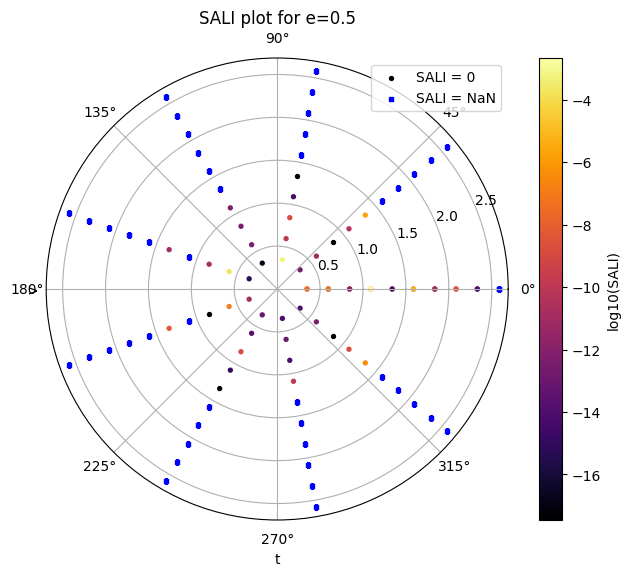

In [76]:
fig, ax = plot_sali(e=0.5, N_v=10, N_t=10, N_it=20)
plt.show()